<a href="https://colab.research.google.com/github/wendykosasih/MAA62052_06_CNN_HYGD/blob/main/MAA62052_06_CNN_HYGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix)

In [ ]:
#================================================
# INPUT DATASET TO COLLAB
#================================================

#1. Image Dataset
IMAGE_DIR = "/content/data/images"

#2. Label Dataset
LABEL_CSV = "/content/data/Labels.csv"

In [ ]:
#================================================
# PARAMETER THAT WILL BE USED IN THIS PROJECT
#================================================
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
#================================================
# LOAD THE DATASET
#================================================
df = pd.read_csv(LABEL_CSV)
df = df.rename(columns={
    "Image Name": "image_name",
    "Patient": "patient_id",
    "Label": "label",
    "Quality Score": "quality"
})

df["image_path"] = df["image_name"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

df["label"] = df["label"].map({"GON+": 1, "GON-": 0})

df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

print("==================================================================")
print("Encoding The Label")
print("==================================================================")
print(f"GON+: 1, GON-: 0 \n")

print("==================================================================")
print("First 10 Data from Dataset")
print("==================================================================")
print(df.head(10), "\n")

print("==================================================================")
print("Dataset Shape")
print("==================================================================")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]} \n")

print("==================================================================")
print("Label Distribution")
print("==================================================================")
print(df["label"].value_counts(), "\n")

print("==================================================================")
print("Quality Score Statistics")
print("==================================================================")
print(df['quality'].describe(), "\n")

print("==================================================================")
print("Total Unique Patient")
print("==================================================================")
print("Unique patients:", df["patient_id"].nunique(), "\n")

print("==================================================================")
print("Image Description")
print("==================================================================")
sample_img = Image.open(df.iloc[0]["image_path"])
print(f"Original image size : {sample_img.size}  (width x height)")
print(f"Image mode          : {sample_img.mode}")

Encoding The Label
GON+: 1, GON-: 0 

First 10 Data from Dataset
  image_name  patient_id  label  quality  Unnamed: 4  \
0    0_0.jpg           0      1     6.18         NaN   
1    1_0.jpg           1      1     5.31         NaN   
2    1_1.jpg           1      1     4.37         NaN   
3    2_0.jpg           2      1     3.51         NaN   
4    2_1.jpg           2      1     4.24         NaN   
5    3_0.jpg           3      1     5.95         NaN   
6    3_1.jpg           3      1     4.22         NaN   
7    4_0.jpg           4      1     5.25         NaN   
8    5_0.jpg           5      1     6.58         NaN   
9    5_1.jpg           5      1     6.67         NaN   

                     image_path  
0  /content/data/images/0_0.jpg  
1  /content/data/images/1_0.jpg  
2  /content/data/images/1_1.jpg  
3  /content/data/images/2_0.jpg  
4  /content/data/images/2_1.jpg  
5  /content/data/images/3_0.jpg  
6  /content/data/images/3_1.jpg  
7  /content/data/images/4_0.jpg  
8  /content/

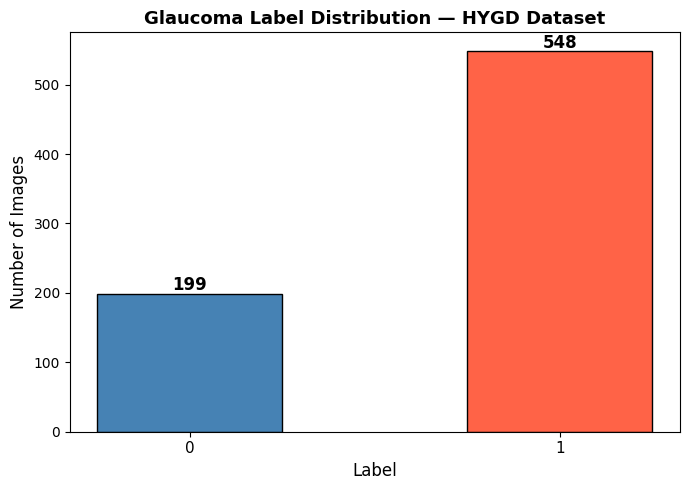

✅ Label distribution chart saved!


In [ ]:
#================================================
# PLOT THE GLAUCOMA LABEL DISTRIBUTION
#================================================
label_counts = df['label'].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(label_counts.index, label_counts.values,
               color=['tomato', 'steelblue'], edgecolor='black', width=0.5)

plt.title('Glaucoma Label Distribution — HYGD Dataset',
          fontsize=13, fontweight='bold')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             val + 5, str(val),
             ha='center', fontweight='bold', fontsize=12)

plt.xticks([0, 1], ['0', '1'], fontsize=11)
plt.tight_layout()
plt.savefig('/content/fig_label_distribution.png', dpi=150)
plt.show()
print("✅ Label distribution chart saved!")

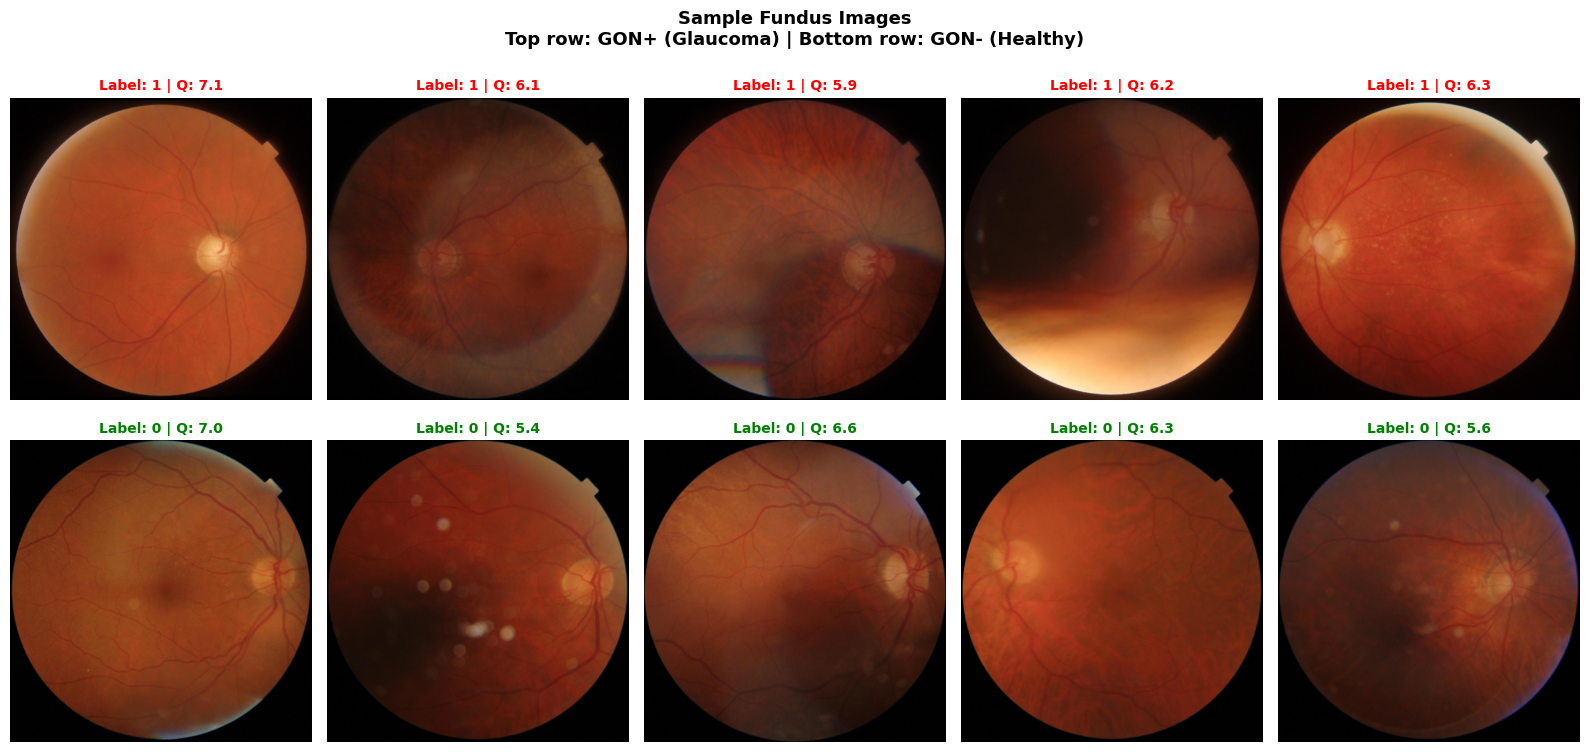

✅ Sample images figure saved!


In [ ]:
#================================================
# SHOWING THE 5 DATA FOR THE GON+ AND GON-
#================================================
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

gon_pos_samples = df[df['label'] == 1].sample(5, random_state=1)
gon_neg_samples = df[df['label'] == 0].sample(5, random_state=1)
samples = pd.concat([gon_pos_samples, gon_neg_samples]).reset_index(drop=True)

for i, row in samples.iterrows():
    img = Image.open(row["image_path"])
    color = 'red' if row['label'] == 1 else 'green'
    axes[i].imshow(img)
    axes[i].set_title(
        f"Label: {row['label']} | Q: {row['quality']:.1f}",
        color=color, fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle(
    'Sample Fundus Images\nTop row: GON+ (Glaucoma) | Bottom row: GON- (Healthy)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig_sample_images.png', dpi=150)
plt.show()
print("✅ Sample images figure saved!")

In [ ]:
#================================================
# Splitting Patient Level
#================================================
patients = df["patient_id"].unique()

train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=SEED
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED
)

train_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
val_df = df[df["patient_id"].isin(val_patients)].reset_index(drop=True)
test_df = df[df["patient_id"].isin(test_patients)].reset_index(drop=True)

print("=================================================")
print("Training Image:", len(train_df))
print("Validation Image:", len(val_df))
print("Test Image:", len(test_df))
print("=================================================\n")

print("=================================================")
print("Train label distribution:")
print("=================================================")
print(train_df['label'].value_counts())
print("=================================================\n")

print("=================================================")
print("Val label distribution:")
print("=================================================")
print(val_df['label'].value_counts())
print("=================================================\n")

print("=================================================")
print("Test label distribution:")
print("=================================================")
print(test_df['label'].value_counts())
print("=================================================\n")

print("=================================================")
print("Train patients:", train_df["patient_id"].nunique())
print("Validation patients:", val_df["patient_id"].nunique())
print("Test patients:", test_df["patient_id"].nunique())
print("=================================================\n")

Training Image: 537
Validation Image: 112
Test Image: 98

Train label distribution:
label
1    393
0    144
Name: count, dtype: int64

Val label distribution:
label
1    80
0    32
Name: count, dtype: int64

Test label distribution:
label
1    75
0    23
Name: count, dtype: int64

Train patients: 201
Validation patients: 43
Test patients: 44



In [ ]:
#================================================
# Data Loading Pipeline
#================================================
class HYGDImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, use_quality_weight=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.use_quality_weight = use_quality_weight

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row["label"], dtype=torch.float32)
        quality = torch.tensor(row["quality"], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        if self.use_quality_weight:
            # Normalize quality from 1-10 into roughly 0.1-1.0
            quality_weight = quality / 10.0
            return image, label, quality_weight

        return image, label

In [ ]:
#================================================
# Data Preprocessing: Data Transform
#================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
#================================================
# Data Preprocessing: Data Imbalanced Handling
#================================================
class_counts = train_df["label"].value_counts().sort_index()
class_weights = 1.0 / class_counts
sample_weights = train_df["label"].map(class_weights).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True)

In [ ]:
#================================================
# LOAD THE DATASET
#================================================
train_dataset = HYGDImageDataset(train_df, train_transform)
val_dataset = HYGDImageDataset(val_df, eval_transform)
test_dataset = HYGDImageDataset(test_df, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Train : {len(train_dataset)} images → {len(train_loader)} batches")
print(f"Val   : {len(val_dataset)} images → {len(val_loader)} batches")
print(f"Test  : {len(test_dataset)} images → {len(test_loader)} batches")

Train : 537 images → 17 batches
Val   : 112 images → 4 batches
Test  : 98 images → 4 batches


In [ ]:
#================================================
# CUSTOM CNN MODEL
#================================================
class CustomGlaucomaCNN(nn.Module):
    def __init__(self):
        super(CustomGlaucomaCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

In [ ]:
#================================================
# BASELINE TRAINING LOOP
#================================================
model = CustomGlaucomaCNN().to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)
best_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "baseline_cnn.pt")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1: Train Loss=0.6884, Val Loss=0.6795
Epoch 2: Train Loss=0.6656, Val Loss=0.6584
Epoch 3: Train Loss=0.6388, Val Loss=0.6307
Epoch 4: Train Loss=0.5966, Val Loss=0.6165
Epoch 5: Train Loss=0.5795, Val Loss=0.6127
Epoch 6: Train Loss=0.5412, Val Loss=0.5818
Epoch 7: Train Loss=0.5069, Val Loss=0.5874
Epoch 8: Train Loss=0.4903, Val Loss=0.4594
Epoch 9: Train Loss=0.4442, Val Loss=0.6193
Epoch 10: Train Loss=0.4037, Val Loss=0.4240


In [ ]:
#================================================
# QUALITY-AWARE
#================================================

quality_train_dataset = HYGDImageDataset(
    train_df,
    train_transform,
    use_quality_weight=True
)

quality_train_loader = DataLoader(
    quality_train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

quality_model = CustomGlaucomaCNN().to(DEVICE)

criterion_none = nn.BCEWithLogitsLoss(reduction="none")

optimizer = torch.optim.Adam(
    quality_model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

for epoch in range(EPOCHS):
    quality_model.train()
    train_loss = 0

    for images, labels, quality_weights in quality_train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        quality_weights = quality_weights.to(DEVICE)

        optimizer.zero_grad()

        logits = quality_model(images)
        losses = criterion_none(logits, labels)

        # Higher-quality images contribute more strongly
        loss = (losses * quality_weights).mean()

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Quality-aware Epoch {epoch+1}: Loss={train_loss / len(quality_train_loader):.4f}")

torch.save(quality_model.state_dict(), "quality_aware_cnn.pt")

Quality-aware Epoch 1: Loss=0.4103
Quality-aware Epoch 2: Loss=0.4021
Quality-aware Epoch 3: Loss=0.3828
Quality-aware Epoch 4: Loss=0.3725
Quality-aware Epoch 5: Loss=0.3547
Quality-aware Epoch 6: Loss=0.3410
Quality-aware Epoch 7: Loss=0.3240
Quality-aware Epoch 8: Loss=0.3055
Quality-aware Epoch 9: Loss=0.3027
Quality-aware Epoch 10: Loss=0.2659


In [ ]:
#================================================
# EVALUATION MODEL
#================================================
def evaluate_model(model, loader):
    model.eval()

    y_true = []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)

            logits = model(images)
            probs = torch.sigmoid(logits).cpu().numpy()

            y_prob.extend(probs)
            y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp)

    results = {
        "Accuracy": acc,
        "Precision": precision,
        "Sensitivity / Recall": sensitivity,
        "Specificity": specificity,
        "F1-score": f1,
        "ROC-AUC": auc,
        "Confusion Matrix": cm
    }

    return results

In [ ]:
#================================================
# SHOWING THE PLOT SYNTAX
#================================================
def show_predictions(model, test_df, transform, num_correct=5, num_incorrect=5):
    model.eval()

    results = []

    for idx in range(len(test_df)):
        row = test_df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = transform(image).unsqueeze(0).to(DEVICE)

        true_label = int(row["label"])

        with torch.no_grad():
            logit = model(image_tensor)
            prob = torch.sigmoid(logit).item()

        pred_label = 1 if prob >= 0.5 else 0

        results.append({
            "image_path": row["image_path"],
            "true_label": true_label,
            "pred_label": pred_label,
            "prob": prob,
            "correct": true_label == pred_label
        })

    correct_results = [r for r in results if r["correct"]]
    incorrect_results = [r for r in results if not r["correct"]]

    show_image_grid(correct_results[:num_correct], "Correct Predictions")
    show_image_grid(incorrect_results[:num_incorrect], "Incorrect Predictions")


def label_name(label):
    return "GON+" if label == 1 else "GON-"


def show_image_grid(results, title):
    if len(results) == 0:
        print(f"No images found for {title}")
        return

    plt.figure(figsize=(4 * len(results), 4))

    for i, r in enumerate(results):
        image = Image.open(r["image_path"]).convert("RGB")

        plt.subplot(1, len(results), i + 1)
        plt.imshow(image)
        plt.axis("off")

        color = "green" if r["correct"] else "red"

        plt.title(
            f"True: {label_name(r['true_label'])}\n"
            f"Pred: {label_name(r['pred_label'])}\n"
            f"Prob: {r['prob']:.2f}",
            color=color,
            fontsize=10
        )

    plt.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

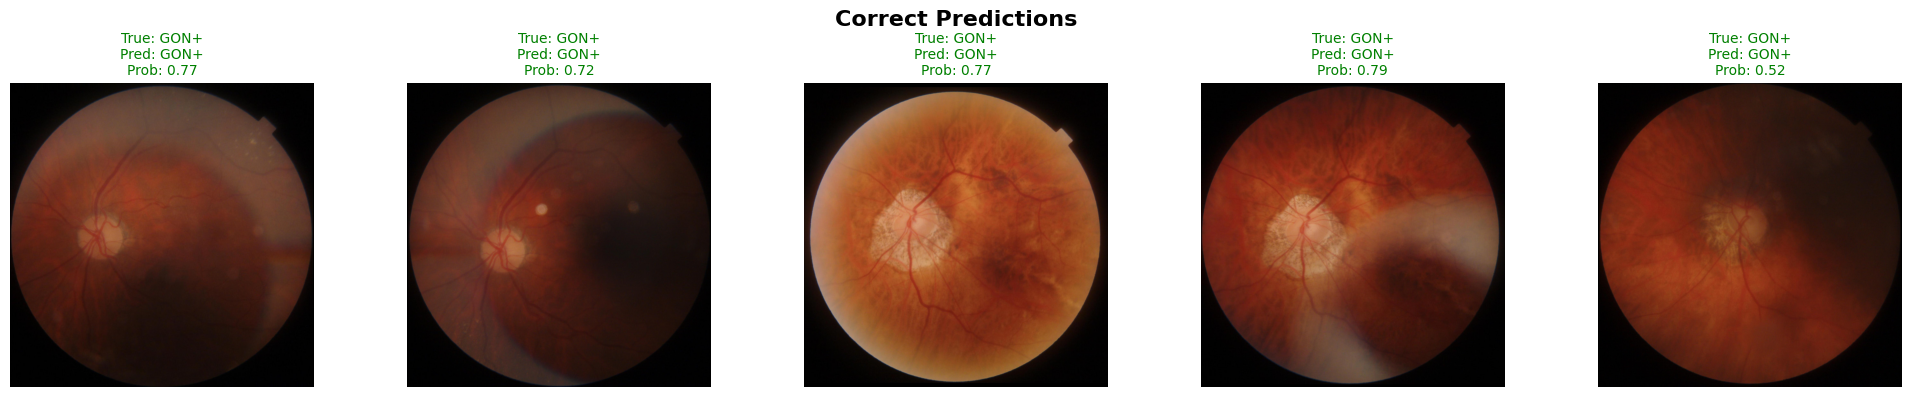

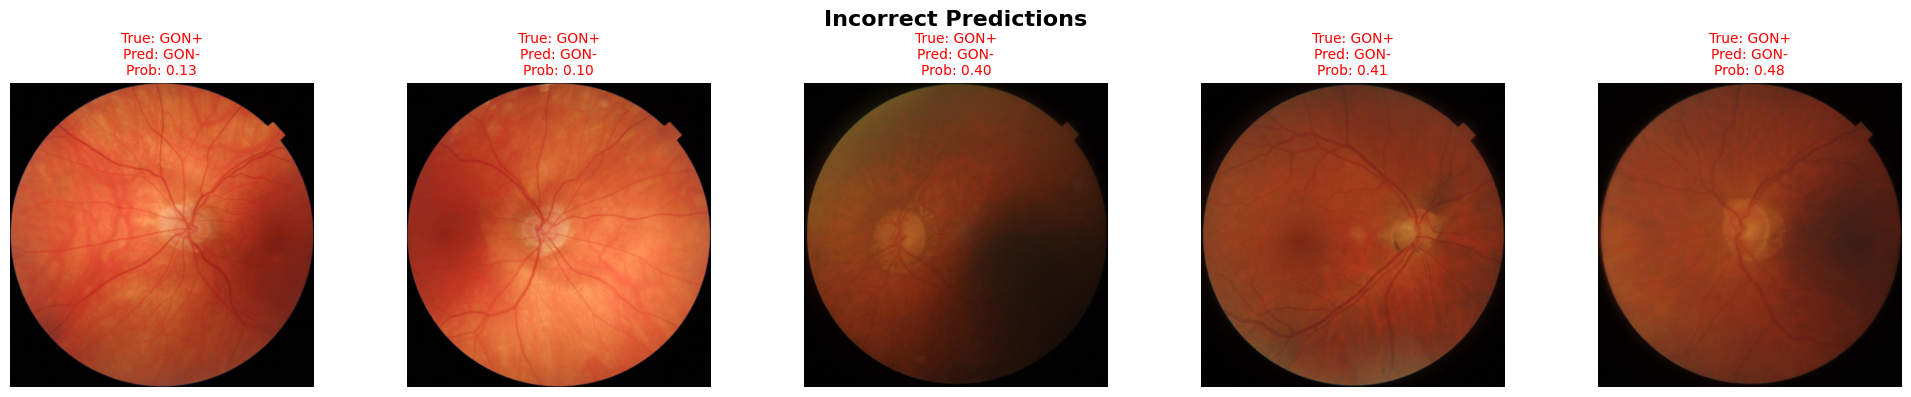

In [ ]:
show_predictions(
    model=model,
    test_df=test_df,
    transform=eval_transform,
    num_correct=5,
    num_incorrect=5
)

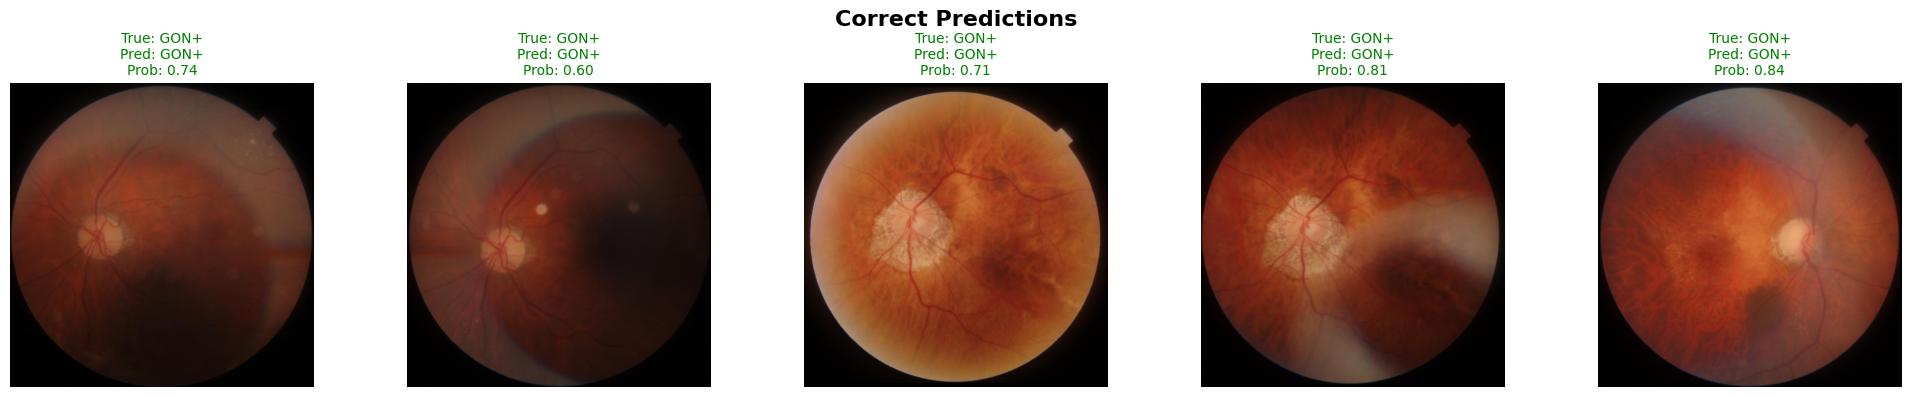

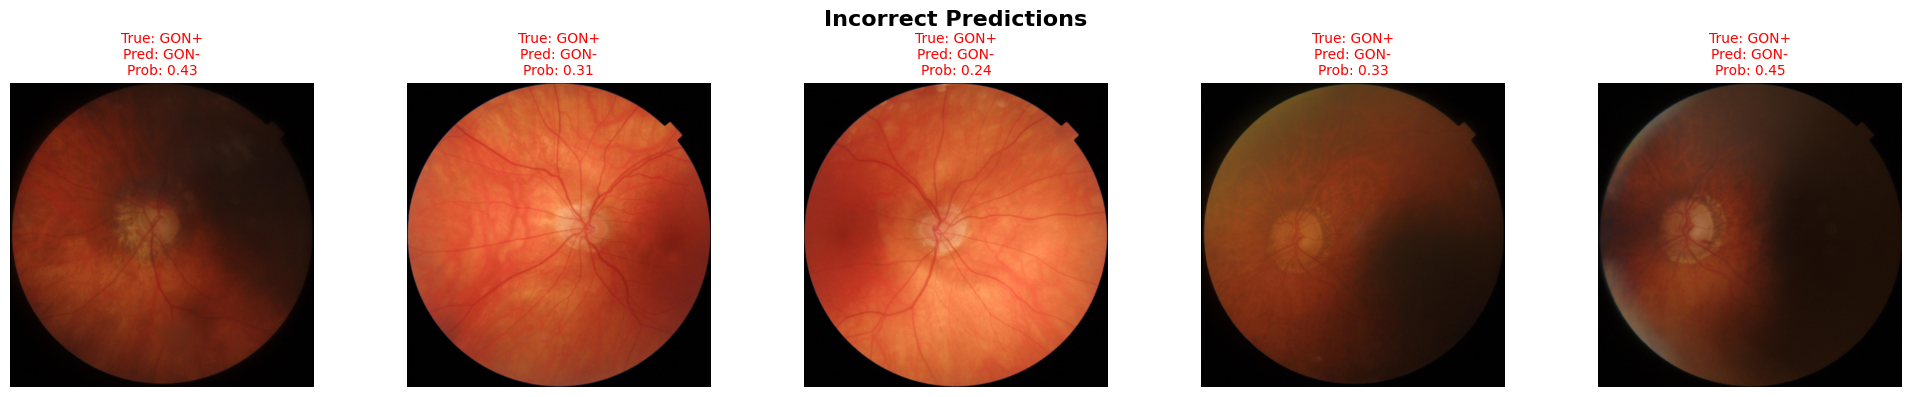

In [ ]:
show_predictions(
    model=quality_model,
    test_df=test_df,
    transform=eval_transform,
    num_correct=5,
    num_incorrect=5
)

In [ ]:
#================================================
# Test Baseline and Quality-Aware Models
#================================================
baseline_model = CustomGlaucomaCNN().to(DEVICE)
baseline_model.load_state_dict(torch.load("baseline_cnn.pt", map_location=DEVICE))

quality_model = CustomGlaucomaCNN().to(DEVICE)
quality_model.load_state_dict(torch.load("quality_aware_cnn.pt", map_location=DEVICE))

baseline_results = evaluate_model(baseline_model, test_loader)
quality_results = evaluate_model(quality_model, test_loader)

print("Baseline CNN Results")
print(baseline_results)

print("Quality-Aware CNN Results")
print(quality_results)

Baseline CNN Results
{'Accuracy': 0.8571428571428571, 'Precision': 0.9841269841269841, 'Sensitivity / Recall': 0.8266666666666667, 'Specificity': np.float64(0.9565217391304348), 'F1-score': 0.8985507246376812, 'ROC-AUC': np.float64(0.9455072463768116), 'Confusion Matrix': array([[22,  1],
       [13, 62]])}
Quality-Aware CNN Results
{'Accuracy': 0.7857142857142857, 'Precision': 0.9821428571428571, 'Sensitivity / Recall': 0.7333333333333333, 'Specificity': np.float64(0.9565217391304348), 'F1-score': 0.8396946564885496, 'ROC-AUC': np.float64(0.9315942028985508), 'Confusion Matrix': array([[22,  1],
       [20, 55]])}


In [ ]:
#================================================
# TABLE RESULTS
#================================================
results_table = pd.DataFrame([
    {
        "Model": "Baseline Custom CNN",
        **{k: v for k, v in baseline_results.items() if k != "Confusion Matrix"}
    },
    {
        "Model": "Quality-Aware CNN",
        **{k: v for k, v in quality_results.items() if k != "Confusion Matrix"}
    }
])

print(results_table)
results_table.to_csv("model_comparison_results.csv", index=False)

                 Model  Accuracy  Precision  Sensitivity / Recall  \
0  Baseline Custom CNN  0.857143   0.984127              0.826667   
1    Quality-Aware CNN  0.785714   0.982143              0.733333   

   Specificity  F1-score   ROC-AUC  
0     0.956522  0.898551  0.945507  
1     0.956522  0.839695  0.931594  


In [ ]:
def plot_confusion_matrix(cm, title="Confusion Matrix"):

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["GON-", "GON+"],
        yticklabels=["GON-", "GON+"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.tight_layout()
    plt.show()

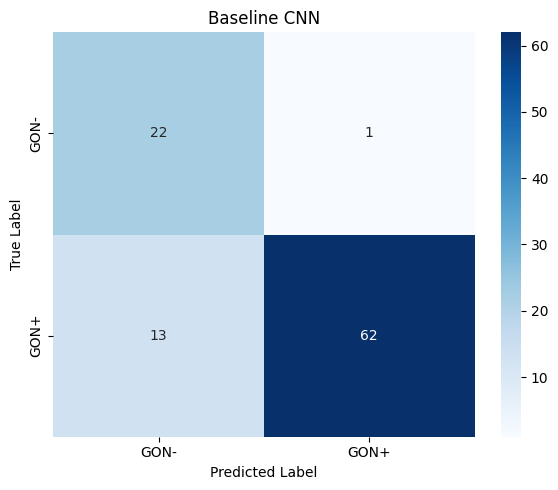

In [ ]:
plot_confusion_matrix(
    baseline_results["Confusion Matrix"],
    title="Baseline CNN"
)

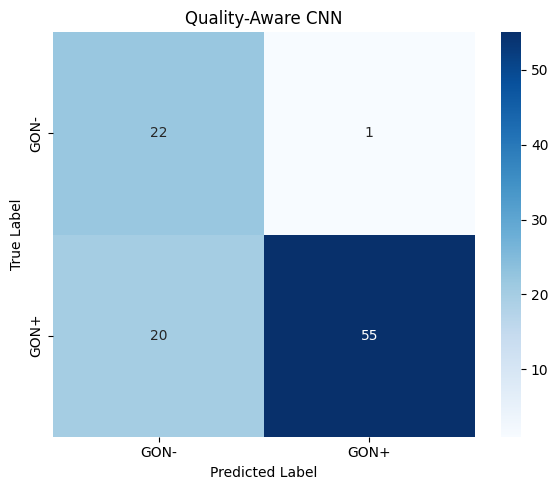

In [ ]:
plot_confusion_matrix(
    quality_results["Confusion Matrix"],
    title="Quality-Aware CNN"
)